In [2]:
# ===============================================================
# FUTURE_ML_03
# AI Resume Screening & Candidate Ranking System
# ===============================================================

"""
Developer : Dikshitha Rasineni

Project:
AI Resume Screening System using Natural Language Processing (NLP)
and Machine Learning.

Objectives
----------
✓ Resume Parsing
✓ Resume Cleaning
✓ Skill Extraction
✓ Job Description Matching
✓ Candidate Ranking
✓ ATS Compatibility Score
✓ Skill Gap Analysis
✓ Recruiter Recommendation
✓ Interactive Dashboard (Streamlit)
"""

'\nDeveloper : Dikshitha Rasineni\n\nProject:\nAI Resume Screening System using Natural Language Processing (NLP)\nand Machine Learning.\n\nObjectives\n----------\n✓ Resume Parsing\n✓ Resume Cleaning\n✓ Skill Extraction\n✓ Job Description Matching\n✓ Candidate Ranking\n✓ ATS Compatibility Score\n✓ Skill Gap Analysis\n✓ Recruiter Recommendation\n✓ Interactive Dashboard (Streamlit)\n'

In [3]:
# ===============================================================
# IMPORT LIBRARIES
# ===============================================================

import os
import re
import string
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
import joblib

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [4]:
# ===============================================================
# DOWNLOAD NLTK RESOURCES
# ===============================================================

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("✅ NLTK Resources Downloaded Successfully")

✅ NLTK Resources Downloaded Successfully


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/dikshithar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/dikshithar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dikshithar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/dikshithar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/dikshithar/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
# ===============================================================
# LOAD SPACY MODEL
# ===============================================================

nlp = spacy.load("en_core_web_sm")

print("✅ spaCy Loaded Successfully")

✅ spaCy Loaded Successfully


In [6]:
# ===============================================================
# LOAD RESUME DATASET
# ===============================================================

resume_df = pd.read_csv("../data/resumes/Resume.csv")

print("=" * 60)
print("✅ Resume Dataset Loaded Successfully")
print("=" * 60)

print("Shape:", resume_df.shape)

print("\nColumns:")
print(resume_df.columns.tolist())

display(resume_df.head())

✅ Resume Dataset Loaded Successfully
Shape: (2484, 4)

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
# ===============================================================
# EXPLORATORY DATA ANALYSIS
# ===============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

resume_df.info()

print("\n")

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(resume_df.isnull().sum())

print("\n")

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print("Duplicate Rows :", resume_df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 52.3 MB


MISSING VALUES
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


DUPLICATE RECORDS
Duplicate Rows : 0


In [8]:
# ===============================================================
# CATEGORY DISTRIBUTION
# ===============================================================

resume_df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

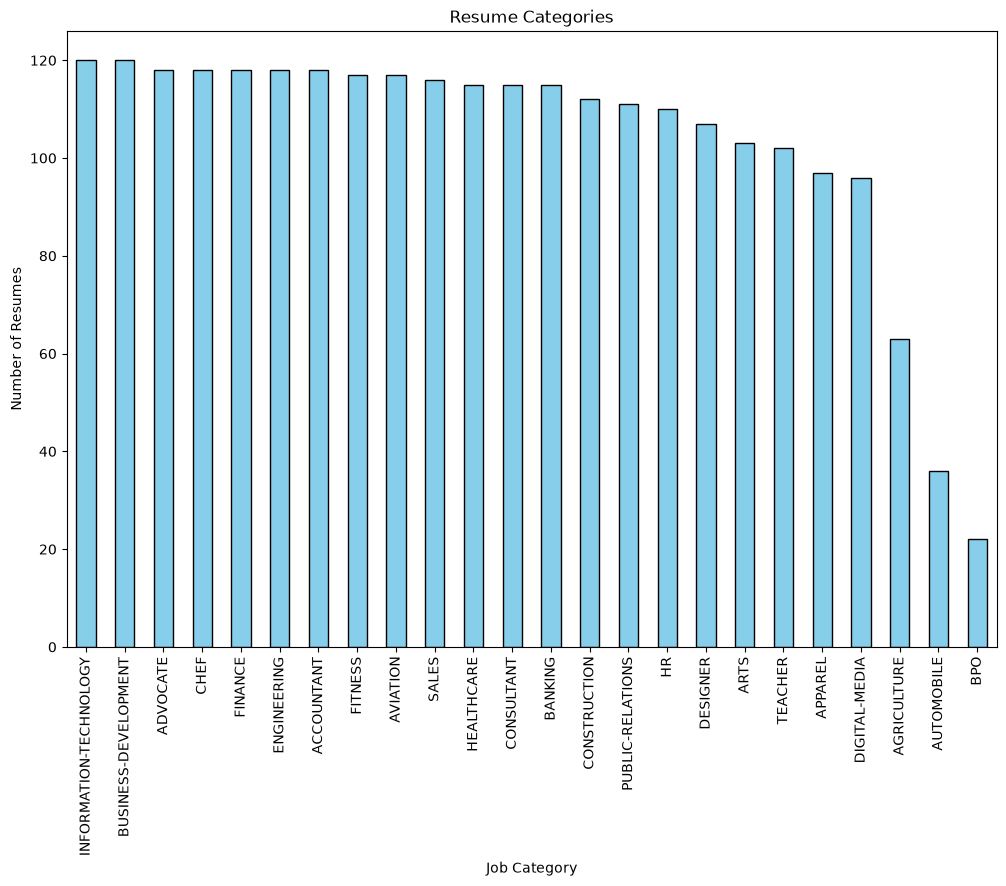

In [9]:
# ===============================================================
# VISUALIZE CATEGORY DISTRIBUTION
# ===============================================================

plt.figure(figsize=(12,8))

resume_df["Category"].value_counts().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Resume Categories")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.show()

In [10]:
# ===============================================================
# RESUME LENGTH ANALYSIS
# ===============================================================

resume_df["Resume_Length"] = resume_df["Resume_str"].astype(str).apply(len)

resume_df["Resume_Length"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_Length, dtype: float64

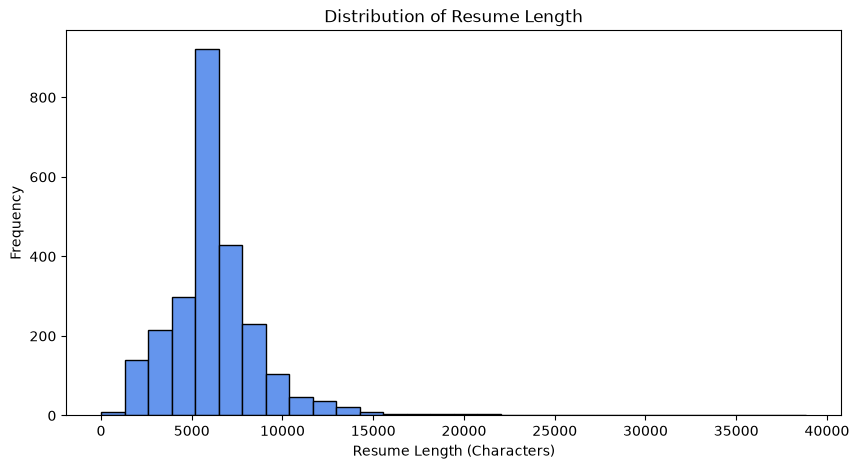

In [11]:
# ===============================================================
# RESUME LENGTH DISTRIBUTION
# ===============================================================

plt.figure(figsize=(10,5))

plt.hist(
    resume_df["Resume_Length"],
    bins=30,
    color="cornflowerblue",
    edgecolor="black"
)

plt.title("Distribution of Resume Length")
plt.xlabel("Resume Length (Characters)")
plt.ylabel("Frequency")

plt.show()

In [12]:
# ===============================================================
# RESUME CLEANING FUNCTION
# ===============================================================

def clean_resume(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Emails
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove Phone Numbers
    text = re.sub(r"\+?\d[\d\s\-]{8,}", " ", text)

    # Remove HTML Tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove Punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove Numbers
    text = re.sub(r"\d+", " ", text)

    # Convert to Lowercase
    text = text.lower()

    # Remove Extra Spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

print("✅ Resume Cleaning Function Created")

✅ Resume Cleaning Function Created


In [13]:
# ===============================================================
# CLEAN RESUME TEXT
# ===============================================================

resume_df["Clean_Resume"] = resume_df["Resume_str"].apply(clean_resume)

resume_df[
    ["Category", "Clean_Resume"]
].head()

,Category,Clean_Resume
0,HR,hr administratormarketing associate hr adminis...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary over years experience in r...
3,HR,hr specialist summary dedicated driven and dyn...
4,HR,hr manager skill highlights hr skills hr depar...


In [14]:
# ===============================================================
# ADVANCED NLP PREPROCESSING USING SPACY
# ===============================================================

stop_words = spacy.lang.en.stop_words.STOP_WORDS

def preprocess_resume(text):

    doc = nlp(str(text))

    tokens = []

    for token in doc:

        if (
            not token.is_stop
            and not token.is_punct
            and not token.is_space
            and not token.like_num
            and len(token.text) > 2
        ):
            tokens.append(token.lemma_.lower())

    return " ".join(tokens)

resume_df["Processed_Resume"] = resume_df["Clean_Resume"].apply(preprocess_resume)

print("✅ Resume Preprocessing Completed")

resume_df[
    ["Processed_Resume"]
].head()

✅ Resume Preprocessing Completed


,Processed_Resume
0,administratormarkete associate administrator s...
1,specialist operation summary versatile media p...
2,director summary year experience recruiting pl...
3,specialist summary dedicate driven dynamic yea...
4,manager skill highlight skill department start...


In [15]:
# ===============================================================
# TECHNICAL SKILL DATABASE
# ===============================================================

SKILLS = {

    # Programming Languages
    "python","java","c","c++","c#","javascript","typescript",
    "php","ruby","go","rust","swift","kotlin","r","matlab",

    # Web Development
    "html","css","react","angular","vue","node","express",
    "django","flask","fastapi","bootstrap","tailwind",

    # Databases
    "sql","mysql","postgresql","mongodb","oracle","sqlite",
    "redis","firebase",

    # AI / Machine Learning
    "machine learning","deep learning","tensorflow","keras",
    "pytorch","scikit-learn","xgboost","opencv","nlp",
    "computer vision","cnn","rnn","lstm","transformer",

    # Cloud & DevOps
    "aws","azure","gcp","docker","kubernetes","jenkins",
    "terraform","linux","git","github",

    # Data Analytics
    "numpy","pandas","matplotlib","seaborn","plotly",
    "power bi","tableau","excel",

    # Mobile
    "android","ios","flutter","react native",

    # CS Fundamentals
    "data structures","algorithms","oop","operating systems",
    "computer networks","dbms"
}

print(f"Total Skills Loaded: {len(SKILLS)}")

Total Skills Loaded: 77


In [16]:
# ===============================================================
# SKILL EXTRACTION FUNCTION
# ===============================================================

def extract_skills(text):

    text = str(text).lower()

    detected_skills = []

    for skill in SKILLS:

        if skill in text:
            detected_skills.append(skill)

    return sorted(list(set(detected_skills)))

print("✅ Skill Extraction Function Created")

✅ Skill Extraction Function Created


In [17]:
# ===============================================================
# EXTRACT SKILLS FROM RESUMES
# ===============================================================

resume_df["Skills"] = resume_df["Processed_Resume"].apply(extract_skills)

resume_df[
    [
        "Category",
        "Skills"
    ]
].head()

,Category,Skills
0,HR,"[c, go, r, swift]"
1,HR,"[c, git, go, oop, r, rust]"
2,HR,"[c, excel, express, go, r]"
3,HR,"[c, excel, r]"
4,HR,"[aws, c, excel, go, r]"


In [18]:
# ===============================================================
# COUNT DETECTED SKILLS
# ===============================================================

resume_df["Skill_Count"] = resume_df["Skills"].apply(len)

resume_df[
    [
        "Category",
        "Skill_Count"
    ]
].head()

,Category,Skill_Count
0,HR,4
1,HR,6
2,HR,5
3,HR,3
4,HR,5


In [19]:
# ===============================================================
# MOST COMMON SKILLS
# ===============================================================

from collections import Counter

all_skills = []

for skill_list in resume_df["Skills"]:
    all_skills.extend(skill_list)

skill_counter = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counter.most_common(25),
    columns=["Skill", "Frequency"]
)

top_skills

,Skill,Frequency
0,c,2483
1,r,2483
2,go,2076
3,excel,1616
4,git,333
5,rust,257
6,oop,203
7,sql,191
8,oracle,171
9,html,153


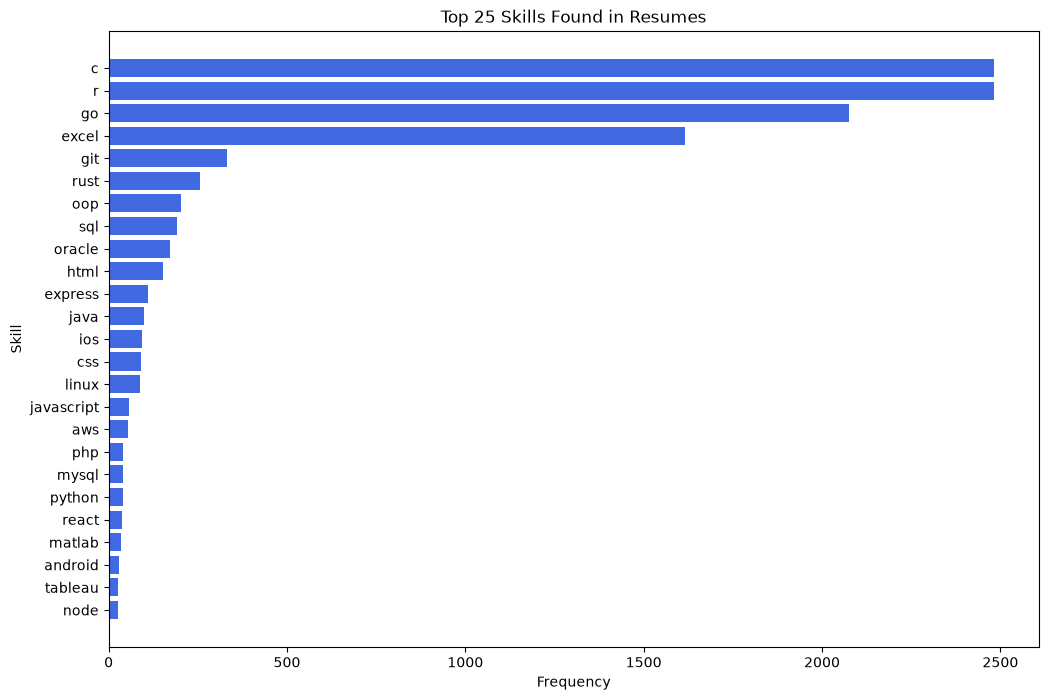

In [20]:
# ===============================================================
# TOP SKILLS VISUALIZATION
# ===============================================================

plt.figure(figsize=(12,8))

plt.barh(
    top_skills["Skill"],
    top_skills["Frequency"],
    color="royalblue"
)

plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.title("Top 25 Skills Found in Resumes")

plt.gca().invert_yaxis()

plt.show()

In [21]:
# ===============================================================
# IMPORT PHRASE MATCHER
# ===============================================================

from spacy.matcher import PhraseMatcher

print("✅ PhraseMatcher Imported")

✅ PhraseMatcher Imported


In [22]:
# ===============================================================
# BUILD PHRASEMATCHER
# ===============================================================

matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

patterns = [nlp.make_doc(skill) for skill in SKILLS]

matcher.add("SKILLS", patterns)

print(f"✅ Matcher Loaded with {len(SKILLS)} Skills")

✅ Matcher Loaded with 77 Skills


In [23]:
# ===============================================================
# ADVANCED SKILL EXTRACTION
# ===============================================================

def extract_skills_spacy(text):

    doc = nlp(str(text))

    matches = matcher(doc)

    skills = []

    for match_id, start, end in matches:
        skills.append(doc[start:end].text.lower())

    return sorted(list(set(skills)))

print("✅ Advanced Skill Extractor Ready")

✅ Advanced Skill Extractor Ready


In [24]:
# ===============================================================
# EXTRACT SKILLS USING SPACY
# ===============================================================

resume_df["Skills"] = resume_df["Processed_Resume"].apply(extract_skills_spacy)

resume_df[
    [
        "Category",
        "Skills"
    ]
].head()

,Category,Skills
0,HR,[swift]
1,HR,[]
2,HR,"[excel, express]"
3,HR,[excel]
4,HR,[excel]


In [25]:
# ===============================================================
# NUMBER OF DETECTED SKILLS
# ===============================================================

resume_df["Skill_Count"] = resume_df["Skills"].apply(len)

resume_df[
    [
        "Category",
        "Skill_Count"
    ]
].head()

,Category,Skill_Count
0,HR,1
1,HR,0
2,HR,2
3,HR,1
4,HR,1


In [26]:
# ===============================================================
# MOST COMMON DETECTED SKILLS
# ===============================================================

from collections import Counter

counter = Counter()

for skills in resume_df["Skills"]:
    counter.update(skills)

top_skills = pd.DataFrame(
    counter.most_common(25),
    columns=["Skill","Frequency"]
)

top_skills

,Skill,Frequency
0,excel,1017
1,sql,175
2,oracle,171
3,html,147
4,go,131
5,linux,84
6,express,81
7,java,66
8,css,66
9,javascript,56


In [27]:
# ===============================================================
# IMPORT SENTENCE TRANSFORMERS
# ===============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ Sentence Transformers Imported")

✅ Sentence Transformers Imported


In [28]:
# ===============================================================
# LOAD EMBEDDING MODEL
# ===============================================================

embedding_model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

print("✅ BGE Embedding Model Loaded Successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ BGE Embedding Model Loaded Successfully


In [29]:
# ===============================================================
# LOAD JOB DESCRIPTION DATASET
# ===============================================================

job_df = pd.read_csv("../data/job_descriptions/job_descriptions.csv")

print("Shape:", job_df.shape)

print("\nColumns:")
print(job_df.columns.tolist())

display(job_df.head())

Shape: (1615940, 23)

Columns:
['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [30]:
# ===============================================================
# KEEP ONLY IMPORTANT COLUMNS
# ===============================================================

job_df = job_df[
    [
        "Job Title",
        "Role",
        "Job Description",
        "skills",
        "Responsibilities",
        "Qualifications",
        "Experience"
    ]
]

job_df.head()

,Job Title,Role,Job Description,skills,Responsibilities,Qualifications,Experience
0,Digital Marketing Specialist,Social Media Manager,Social Media Managers oversee an organizations...,"Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",M.Tech,5 to 15 Years
1,Web Developer,Frontend Web Developer,Frontend Web Developers design and implement u...,"HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",BCA,2 to 12 Years
2,Operations Manager,Quality Control Manager,Quality Control Managers establish and enforce...,Quality control processes and methodologies St...,Establish and enforce quality control standard...,PhD,0 to 12 Years
3,Network Engineer,Wireless Network Engineer,"Wireless Network Engineers design, implement, ...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",PhD,4 to 11 Years
4,Event Manager,Conference Manager,A Conference Manager coordinates and manages c...,Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,MBA,1 to 12 Years


In [31]:
SKILLS.discard("c")
SKILLS.discard("r")

In [32]:
# ===============================================================
# FAST SKILL EXTRACTION
# ===============================================================

def extract_skills_fast(text):

    text = str(text).lower()

    skills_found = []

    for skill in SKILLS:
        if skill.lower() in text:
            skills_found.append(skill)

    return sorted(set(skills_found))


job_df["Required_Skills"] = job_df["skills"].fillna("").apply(
    extract_skills_fast
)

print("✅ Skill Extraction Completed")

job_df[
    [
        "Job Title",
        "Required_Skills"
    ]
].head()

✅ Skill Extraction Completed


,Job Title,Required_Skills
0,Digital Marketing Specialist,[]
1,Web Developer,"[angular, css, html, java, javascript, react]"
2,Operations Manager,[]
3,Network Engineer,[]
4,Event Manager,[]


In [33]:
import os

os.makedirs("../models", exist_ok=True)

job_df.to_pickle("../models/processed_jobs.pkl")
resume_df.to_pickle("../models/processed_resumes.pkl")

print("✅ Processed datasets saved successfully!")

✅ Processed datasets saved successfully!


In [34]:
# ===============================================================
# LOAD EMBEDDING MODEL
# ===============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedding_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

print("✅ Embedding Model Loaded Successfully")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding Model Loaded Successfully


In [35]:
# ===============================================================
# SELECT JOB ROLE
# ===============================================================

role = "Software Engineer"

filtered_jobs = job_df[
    job_df["Job Title"].str.contains(
        role,
        case=False,
        na=False
    )
]

print("Matching Jobs:", len(filtered_jobs))

selected_job = filtered_jobs.iloc[0]

print(selected_job["Job Title"])

Matching Jobs: 27630
Software Engineer


In [36]:
# ===============================================================
# CREATE EMBEDDINGS
# ===============================================================

resume_embeddings = embedding_model.encode(
    resume_df["Processed_Resume"].tolist(),
    show_progress_bar=True
)

job_embedding = embedding_model.encode(
    [selected_job["Job Description"]]
)

print("✅ Embeddings Created")

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

✅ Embeddings Created


In [37]:
# ===============================================================
# CALCULATE SIMILARITY
# ===============================================================

similarity_scores = cosine_similarity(
    resume_embeddings,
    job_embedding
).flatten()

resume_df["Similarity"] = similarity_scores

resume_df[
    [
        "Category",
        "Similarity"
    ]
].head()

,Category,Similarity
0,HR,0.570092
1,HR,0.607757
2,HR,0.563754
3,HR,0.611203
4,HR,0.573820


In [38]:
# ===============================================================
# TOP MATCHING CANDIDATES
# ===============================================================

top_candidates = resume_df.sort_values(
    by="Similarity",
    ascending=False
)

top_candidates[
    [
        "Category",
        "Similarity",
        "Skills"
    ]
].head(10)

,Category,Similarity,Skills
311,INFORMATION-TECHNOLOGY,0.752715,"[bootstrap, css, excel, github, html, java, ja..."
309,INFORMATION-TECHNOLOGY,0.752551,"[bootstrap, css, excel, github, html, java, ja..."
291,INFORMATION-TECHNOLOGY,0.730051,"[css, html, ios, java, javascript, oracle, php..."
1323,AUTOMOBILE,0.718606,"[oracle, sql]"
128,DESIGNER,0.714690,"[express, go, java, linux, mysql, oop, oracle,..."
120,DESIGNER,0.711290,"[css, go, html, javascript, mysql, php, sql]"
1111,CONSULTANT,0.709378,"[angular, bootstrap, css, excel, github, html,..."
1747,ENGINEERING,0.704990,"[css, html, javascript, node, oop]"
1195,CONSULTANT,0.702047,"[html, java, javascript, linux, mysql, oracle]"
2184,BANKING,0.701275,"[azure, css, html, javascript, oracle, sql]"


In [39]:
# ===============================================================
# GENERATE RESUME EMBEDDINGS
# ===============================================================

resume_embeddings = embedding_model.encode(
    resume_df["Processed_Resume"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("✅ Resume Embeddings Generated")
print("Shape:", resume_embeddings.shape)

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

✅ Resume Embeddings Generated
Shape: (2484, 384)


In [40]:
# ===============================================================
# GENERATE JOB EMBEDDING
# ===============================================================

job_embedding = embedding_model.encode(
    [selected_job["Job Description"]],
    convert_to_numpy=True
)

print("✅ Job Embedding Generated")

✅ Job Embedding Generated


In [41]:
# ===============================================================
# CALCULATE COSINE SIMILARITY
# ===============================================================

similarity_scores = cosine_similarity(
    resume_embeddings,
    job_embedding
).flatten()

resume_df["Similarity"] = similarity_scores

resume_df[
    [
        "Category",
        "Similarity"
    ]
].head()

,Category,Similarity
0,HR,0.570092
1,HR,0.607757
2,HR,0.563754
3,HR,0.611203
4,HR,0.573820


In [42]:
# ===============================================================
# RANK CANDIDATES
# ===============================================================

ranked_candidates = resume_df.sort_values(
    by="Similarity",
    ascending=False
)

ranked_candidates[
    [
        "Category",
        "Similarity",
        "Skill_Count",
        "Skills"
    ]
].head(10)

,Category,Similarity,Skill_Count,Skills
311,INFORMATION-TECHNOLOGY,0.752715,9,"[bootstrap, css, excel, github, html, java, ja..."
309,INFORMATION-TECHNOLOGY,0.752551,9,"[bootstrap, css, excel, github, html, java, ja..."
291,INFORMATION-TECHNOLOGY,0.730051,9,"[css, html, ios, java, javascript, oracle, php..."
1323,AUTOMOBILE,0.718606,2,"[oracle, sql]"
128,DESIGNER,0.714690,10,"[express, go, java, linux, mysql, oop, oracle,..."
120,DESIGNER,0.711290,7,"[css, go, html, javascript, mysql, php, sql]"
1111,CONSULTANT,0.709378,10,"[angular, bootstrap, css, excel, github, html,..."
1747,ENGINEERING,0.704990,5,"[css, html, javascript, node, oop]"
1195,CONSULTANT,0.702047,6,"[html, java, javascript, linux, mysql, oracle]"
2184,BANKING,0.701275,6,"[azure, css, html, javascript, oracle, sql]"


In [43]:
# ===============================================================
# SKILL MATCH SCORE
# ===============================================================

job_skills = set(selected_job["Required_Skills"])

print("Job Skills:", job_skills)

def calculate_skill_match(resume_skills):

    resume_skills = set(resume_skills)

    return round(
        len(job_skills.intersection(resume_skills)) / len(job_skills) * 100,
        2
    )

resume_df["Skill_Match"] = resume_df["Skills"].apply(calculate_skill_match)

print("\nFirst Resume Skills:")
print(resume_df.iloc[309]["Skills"])

print("\nFirst Resume Skill Match:")
print(resume_df.iloc[309]["Skill_Match"])

Job Skills: {'python', 'ruby', 'java', 'sql', 'node', 'go', 'express', 'django'}

First Resume Skills:
['bootstrap', 'css', 'excel', 'github', 'html', 'java', 'javascript', 'mysql', 'sql']

First Resume Skill Match:
25.0


In [44]:
# ===============================================================
# ATS SCORING ENGINE
# ===============================================================

def calculate_ats_score(
    similarity,
    skill_match,
    experience_match,
    education_match,
    completeness
):

    score = (

        similarity * 100 * 0.40

        +

        skill_match * 0.35

        +

        experience_match * 0.10

        +

        education_match * 0.05

        +

        completeness * 0.10

    )

    return round(score,2)

In [45]:
# ===============================================================
# RESUME COMPLETENESS
# ===============================================================

def resume_completeness(text):

    text = text.lower()

    score = 0

    keywords = [

        "experience",
        "education",
        "project",
        "skill",
        "certification"

    ]

    for word in keywords:

        if word in text:

            score += 20

    return score


resume_df["Resume_Completeness"] = (
    resume_df["Resume_str"]
    .apply(resume_completeness)
)

resume_df[
    [
        "Category",
        "Resume_Completeness"
    ]
].head()

,Category,Resume_Completeness
0,HR,80
1,HR,80
2,HR,80
3,HR,60
4,HR,80


In [46]:
# ===============================================================
# EXPERIENCE MATCH
# ===============================================================

def experience_match(text):

    text = text.lower()

    if "5 years" in text or "five years" in text:

        return 100

    elif "3 years" in text:

        return 80

    elif "2 years" in text:

        return 60

    elif "1 year" in text:

        return 40

    else:

        return 20


resume_df["Experience_Match"] = (
    resume_df["Resume_str"]
    .apply(experience_match)
)

In [47]:
# ===============================================================
# EDUCATION MATCH
# ===============================================================

degrees = [
    "b.tech",
    "btech",
    "b.e",
    "be",
    "m.tech",
    "mtech",
    "mba",
    "phd",
    "bca",
    "mca"
]

def education_match(text):

    text = text.lower()

    for degree in degrees:

        if degree in text:

            return 100

    return 40


resume_df["Education_Match"] = (
    resume_df["Resume_str"]
    .apply(education_match)
)

In [48]:
# ===============================================================
# FINAL ATS SCORE
# ===============================================================

resume_df["ATS_Score"] = resume_df.apply(

    lambda row:

    calculate_ats_score(

        row["Similarity"],
        row["Skill_Match"],
        row["Experience_Match"],
        row["Education_Match"],
        row["Resume_Completeness"]

    ),

    axis=1

)

resume_df["ATS_Score"] = (
    resume_df["ATS_Score"]
    .clip(0,100)
)

resume_df[
    [
        "Category",
        "ATS_Score"
    ]
].head()

,Category,ATS_Score
0,HR,37.80
1,HR,39.31
2,HR,49.93
3,HR,34.45
4,HR,37.95


In [53]:
def recommendation(score):

    if score >= 60:
        return "⭐ Strong Hire"

    elif score >= 50:
        return "✅ Hire"

    elif score >= 45:
        return "⚠️ Consider"

    else:
        return "❌ Reject"

In [54]:
# ===============================================================
# FINAL RANKING
# ===============================================================

final_candidates = resume_df.sort_values(
    by="ATS_Score",
    ascending=False
)

final_candidates[
    [
        "Category",
        "ATS_Score",
        "Skill_Match",
        "Similarity",
        "Recommendation"
    ]
].head(10)

,Category,ATS_Score,Skill_Match,Similarity,Recommendation
128,DESIGNER,65.46,62.5,0.714690,✅ Hire
297,INFORMATION-TECHNOLOGY,65.29,50.0,0.669681,✅ Hire
926,AGRICULTURE,63.49,37.5,0.684167,✅ Hire
291,INFORMATION-TECHNOLOGY,63.33,37.5,0.730051,✅ Hire
124,DESIGNER,62.57,37.5,0.661034,✅ Hire
1799,ENGINEERING,61.12,37.5,0.624958,✅ Hire
1127,CONSULTANT,58.09,25.0,0.658386,⚠️ Consider
311,INFORMATION-TECHNOLOGY,57.86,25.0,0.752715,⚠️ Consider
309,INFORMATION-TECHNOLOGY,57.85,25.0,0.752551,⚠️ Consider
976,BPO,57.73,25.0,0.599550,⚠️ Consider
